This page presents the analytical steps following exploratory data analysis (EDA) and data pre-processing shown in the [previous page](https://znogbes.github.io/sebastian-gonzalez-portfolio//portfolio/portfolio-1/). The next step in our analytical pipeline is to explore and compare modelling approaches. Here, I cover how to **create a logistic regression model** to predict whether a person will pay a loan back. 

I've chosen logistic regression as my initial model because it's a well-known and understood methodology. The idea is to compare this 'classic' model with other approaches to arrive at an optimal model, understanding advantages and drawbacks of using a method over another.   

I'll be using `scikit-learn` along other packages shown below. The specific environment used for the entire project is available [here](https://github.com/znogbes/kaggle-predicting-loan-payback/blob/main/environment.yml).

In [1]:
# set up
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# ml methods
from sklearn.model_selection import train_test_split, cross_validate, \
    cross_val_predict, StratifiedKFold, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import RocCurveDisplay, confusion_matrix,\
    ConfusionMatrixDisplay, classification_report

## Import processed data

Previously, I **encoded the raw data** obtained from Kaggle to make sure it was **fit for machine learning**. Here, I export it form a local directory and check the features after encoding.



In [ ]:
# read encoded data
data_encoded = pd.read_csv('./data/data_train_processed.csv')
# the data_test.csv provided by kaggle doesn't have labels
# so data for splitting, model training, and testing will come from 'data_train'
# make a copy of encoded data to use for modelling
data = data_encoded.copy()
# check encoded version of data is what has been uploaded
features = sorted(data.columns)

<details markdown="1">
<summary><b>Show all 31 features</b></summary>

In [3]:
features

['annual_income',
 'credit_score',
 'debt_to_income_ratio',
 "education_level_Bachelor's",
 'education_level_High School',
 "education_level_Master's",
 'education_level_Other',
 'education_level_PhD',
 'employment_status_Employed',
 'employment_status_Retired',
 'employment_status_Self-employed',
 'employment_status_Student',
 'employment_status_Unemployed',
 'gender_Female',
 'gender_Male',
 'gender_Other',
 'grade_subgrade',
 'interest_rate',
 'loan_amount',
 'loan_paid_back',
 'loan_purpose_Business',
 'loan_purpose_Car',
 'loan_purpose_Debt consolidation',
 'loan_purpose_Education',
 'loan_purpose_Home',
 'loan_purpose_Medical',
 'loan_purpose_Other',
 'loan_purpose_Vacation',
 'marital_status_Divorced',
 'marital_status_Married',
 'marital_status_Single',
 'marital_status_Widowed']

</details>

## Pre-modelling steps

### Separate features and labels

We'll begin by saving the predicting variables (features) in a separate data object from the labels (payers *vs.* non-payers) 

In [4]:
# separate features and labels (outcome) 
X = data.drop('loan_paid_back', axis=1)
y = data['loan_paid_back']

### Split data

Before we go into any models, it's crucial to split the data into training/validation and testing sets. We'll use **80% of the data for training/validation**, and the remaining **20% for testing**. We use this approach so the final model can be used on data it hasn't seen before (i.e., the testing set), which gives us an idea of whether overfitting is occurring. Note that `train_test_split()` **stratifies the data**, which means the [label imbalance](https://znogbes.github.io/sebastian-gonzalez-portfolio//portfolio/portfolio-1/#class-balance) (*payer vs. non payers*) observed in the global data set is **preserved** in the training/validation and test sets.   

In [5]:
# data splits: training, validation, and testing 
# (80% for training/validation, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=17)

### Standardise data

As you might have noticed in the [histograms](https://znogbes.github.io/sebastian-gonzalez-portfolio//portfolio/portfolio-1/#histograms) and [boxplots](https://znogbes.github.io/sebastian-gonzalez-portfolio//portfolio/portfolio-1/#box-plots) produced during EDA, we have **data in different numeric scales**. For instance, `annual_income` and `loan_amount` are expressed in thousands whereas `intesrest_rate` is expressed as a percentage. 

To account for the different ranges in these numeric scales, we will **standardise** the data objects containing training and testing features. After standardisation, the **mean of our numeric data will be 0** and the **standard deviation will be 1**. Note that standardisation is applied to both training and testing feature sets, but **the scaler object applied to both sets is based on the training data**.

In [6]:
# function to standardise data (mean = 0, stdev = 1)
def standardise_data(X_train, X_test):
    # intialise scaling object 
    sc = StandardScaler()
    # set on the training set
    sc.fit(X_train)
    # apply scaler
    train_std = sc.fit_transform(X_train)
    test_std = sc.fit_transform(X_test)
    return train_std, test_std

X_train_std, X_test_std = standardise_data(X_train, X_test)

## Fit logistic regression

### K-fold cross validation

Below, we create a model object with the method of our choice, in this case logistic regression. Note that we set a `class_weight` argument within the model to account for the [imbalance between classes](https://znogbes.github.io/sebastian-gonzalez-portfolio//portfolio/portfolio-1/#class-balance) observed during EDA. This argument applies weights to each class as specified in the `scikit-learn` [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). 

We **fit that model using the standardised features** and the **labels from the training/validation set**. Note that we use *k-fold cross validation* to randomly **shuffle our training/validation data** k-number of times. In this case, the regression will be run 10 times, each time using a different section of the data set for training and another for validation. The model will be tested on the validation set so it can return performance metrics, which we can average across the 10 runs. We can also set the `cross_validate()` method to return the generated models so we can extract coefficients.

In [7]:
# start modelling
# approach 1 - logistic regressions
model = LogisticRegression(class_weight='balanced')

# defaulted to stratified cross validation (cv) - i.e., percentage of sample 
# in each label is kept consistent as possible
cv_results = cross_validate(
    model, X_train_std, y_train,
    # performance metrics to calculate
    scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'],
    n_jobs=-1,
    # number of folds
    cv=10,
    # return trained models for each fold
    return_estimator=True # increases running time a little
    )

### Extract coefficients

Using the generated models stored in our cross-validation results, we can calculate the mean coefficient for every feature across all 10 runs of the logistic regression. We can then create a table with every feature and its average coefficient. If you get the absolute value of the coefficients and sort them in descending order, you will see which features had the largest effect at predicting loan payback, regardless of whether that effect was positive or negative. I'll present the 10 features with the greatest influence, but feel free to check the rest by clicking on the arrow.

In [8]:
# extract coefficients from models generated in cross val
co_eff_df = pd.DataFrame()
co_eff_df['feature'] = list(X_train.columns)

coefficients = []
for model in cv_results['estimator']:
    # append array of coefficients
    coefficients.append(model.coef_[0])

# calculate mean coefficient for every feature
mean_coefficients = np.mean(coefficients, axis = 0)
# save into coeff df
co_eff_df['mean_coefficient_cv10'] = mean_coefficients
# sort by absolute value (derived from mean coeff to understand magnitude)
co_eff_df['co_efficient_abs'] = np.abs(co_eff_df['mean_coefficient_cv10'])
co_eff_df.sort_values(by='co_efficient_abs', ascending=False, inplace=True)
# present 10 top features by absolute coefficient value
co_eff_df[0:10]

,feature,mean_coefficient_cv10,co_efficient_abs
22,employment_status_Unemployed,-1.193945,1.193945
1,debt_to_income_ratio,-0.911103,0.911103
2,credit_score,0.891188,0.891188
19,employment_status_Retired,0.819979,0.819979
18,employment_status_Employed,0.448938,0.448938
21,employment_status_Student,-0.317935,0.317935
20,employment_status_Self-employed,0.295849,0.295849
5,grade_subgrade,0.106203,0.106203
4,interest_rate,-0.057440,0.057440
27,loan_purpose_Home,0.030958,0.030958


<details markdown="1">
<summary><b>Show all feature coefficients (31)</b></summary>

In [9]:
co_eff_df

,feature,mean_coefficient_cv10,co_efficient_abs
22,employment_status_Unemployed,-1.193945,1.193945
1,debt_to_income_ratio,-0.911103,0.911103
2,credit_score,0.891188,0.891188
19,employment_status_Retired,0.819979,0.819979
18,employment_status_Employed,0.448938,0.448938
21,employment_status_Student,-0.317935,0.317935
20,employment_status_Self-employed,0.295849,0.295849
5,grade_subgrade,0.106203,0.106203
4,interest_rate,-0.057440,0.057440
27,loan_purpose_Home,0.030958,0.030958


</details>

## Model evaluation

### Confusion matrix

Evaluation metrics of model performance assess correct *vs.* incorrect predictions of a model. Before diving into specific metric evaluation, you can make a visual assessment of model performance via a confusion matrix. We can plot the rates of true positives and true negatives (i.e., the correct predictions) and the rate of false positives and false negatives (i.e., the incorrect predictions). To compute these rates, we need to compare model predictions *vs.* actual labels in the data. The `ConfusionMatrixDisplay()` and `from_estimator()` methods can do just that!

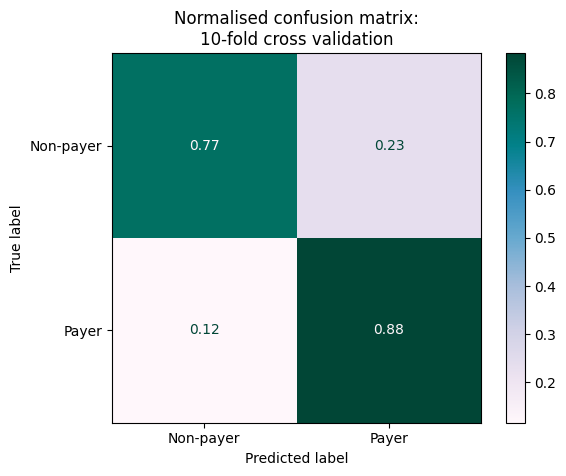

In [10]:
ConfusionMatrixDisplay.from_estimator(model, X_train_std, y_train, 
                                      display_labels=['Non-payer','Payer'],
                                      cmap='PuBuGn',
                                      normalize='true')
plt.title('Normalised confusion matrix:\n10-fold cross validation')
plt.show()

Our logistic regression does well at predicting *loan payers*: **88% of those predicted to be a payer were indeed one** *vs* 12% predicted not to be a payer, who actually did pay back (i.e., false negatives). In contrast, 77% of non-payers were predicted correctly, but **23% were wrongly assigned to the payer group**. In a real world scenario, this **false positive rate** would have important **financial implications:** 23% represents 22,081 loans that were not paid back but the model predicted were paid. Imagine if each loan was worth £5,000 on average! 

We'll see below that logistic regression performs well overall, but we would still benefit from further tuning or other methods to address the false positive rate.


### Performance metrics

Along with the 10 logistic regressions, the `cross_validate()` method returned 4 performance metrics: `accuracy`, `precision`, `recall`, and `F1 score`. Each of these metrics was calculated 10 times, each time by testing the generated model on the validation set for the corresponding k-fold. Since the initial `model` object was a logistic regression weighted to account imbalanced classes, I deemed appropriate to request **performance metrics that also weighted class imbalance**. We can plot the distributions of those metrics across the 10 runs in a boxplot.

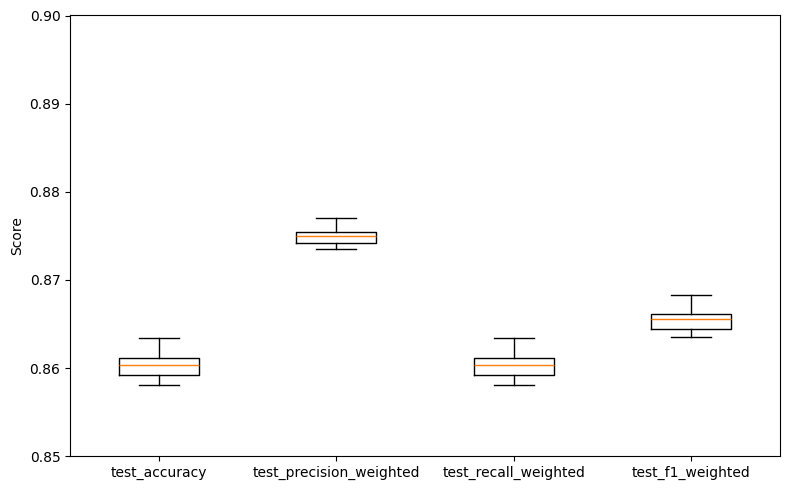

In [11]:
# plot distribution of performance metrics shown in classification report
performance_metrics = pd.DataFrame(cv_results).drop(
    columns=['fit_time', 'score_time', 'estimator'])

# plot metrics obtained via stratified kfolds
# the test_ metrics refer to the the 10th fold 
plt.subplots(figsize=(8,5))
plt.boxplot(performance_metrics, labels=performance_metrics.columns)
plt.ylim(0.85, 0.9)
plt.ylabel('Score')
plt.tight_layout()
plt.show()

The plot suggests the **performance scores were relatively stable between model runs** for all measures of interest, given the narrow range between the boxes' whiskers. We have **generally good scores** across measures (>0.85) but it's still worth going through them. 

The model was generally accurate (i.e., the proportion of correctly classified labels was high), but that alone mustn't be used to interpret performance - which is why precision, recall, and F1 scores are needed. 

**The model was more precise than sensitive**, which means it was better at labelling payers correctly (when it made a prediction) than it was at finding all cases of payers in the data. This all boils down to having **more false negatives than false positives**, which we can see in the non-normalised confusion matrix below. 

The F1 score balances precision and recall, so it will be more useful when we compare modelling methods. More information about the methodology used to apply weights to these measures is available [here](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html). 

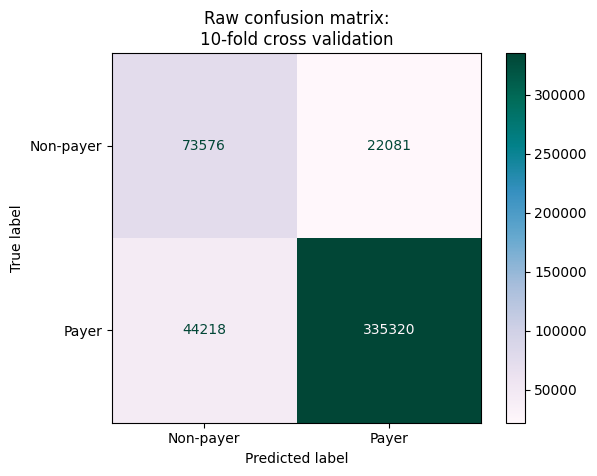

In [12]:
ConfusionMatrixDisplay.from_estimator(model, X_train_std, y_train, 
                                      display_labels=['Non-payer','Payer'],
                                      cmap='PuBuGn'
                                      )
plt.title('Raw confusion matrix:\n10-fold cross validation')
plt.show()


### ROC curve

Using a receiving operator characteristic (ROC) curve, we can **plot the true positive rate against the false positive rate**, as well as calculate AUC (area under the curve). Making a ROC curve plot is **useful to see how the model fares against randomness**. The dotted line in the plot represents a random classifier, that is a scenario where a model is no better at predicting outcomes than random chance. It is useful to plot this line as a benchmark. The more the ROC curve approaches the top left corner of the plot, the closer the model is to be a perfect classifier. 

Overall, our logistic regression fares well using this assessment, but **there could still be room for improvement**, which we might achieve in other models.

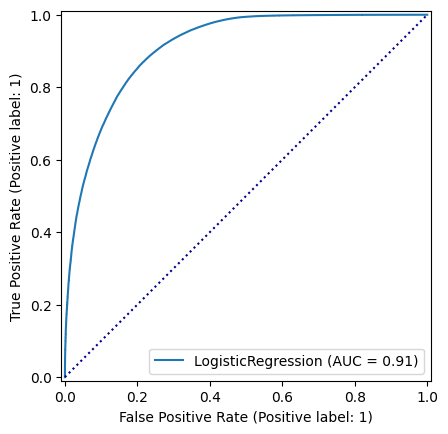

In [13]:
# receiver operator characteristic curve
# plot specificity (false positive rate) vs recall (aka sensitivity; true positive rate) 
roc_curve = RocCurveDisplay.from_estimator(model, X_train_std, y_train, pos_label=1)
fig = roc_curve.figure_
ax = roc_curve.ax_
# plot chance
ax.plot([0,1], [0,1], color='darkblue', linestyle=':')
plt.show()

## Repeat with SMOTE data

Remember the synthethic data generated during EDA? We will bring it here to repeat logistic regression fitting and evaluation. The main change to note between this new run and the previous model is that we won't be requesting class-weighted performance metrics. SMOTE takes care of class imbalance by evening out the numbers of payers and non-payers, which we achieved by generating synthetic non-payers. This also means that the re-run below uses a larger data set.

As you will see below, the model performance improvements achieved by using SMOTE-augmented data are small. In comparison with the first logistic regression, the confusion matrix from the second regression has slightly smaller proportions of correct predictions. However, the proportion of wrongly-predicted non-payers could still be a concern in business contexts, which should encourage us to explore other ML methods to achieve smaller false positive rate without overfitting.    

<details markdown="1">
<summary><b>SMOTE data splitting and standardisation</b></summary>

In [ ]:
data_encoded_smote = pd.read_csv('./data/data_processed_after_smote.csv')
data_augmented = data_encoded_smote.copy()
data_augmented = data_augmented.drop(columns=['is_synthetic', 
                                        'nearest_neighbour_distance', 
                                        'nearest_neighbour_index_real_data'])
# separate features and labels (outcome) 
X = data_augmented.drop('loan_paid_back', axis=1)
y = data_augmented['loan_paid_back']

# data splits: training, validation, and testing 
# (80% for training/validation, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=17)

# standardise data
X_train_std, X_test_std = standardise_data(X_train, X_test)

</details>

<details markdown="1">
<summary><b>Logistic regression coefficients</b></summary>

In [ ]:
# choose model
model = LogisticRegression()

# defaulted to stratified cross validation (cv) - i.e., percentage of sample 
# in each label is kept consistent as possible
cv_results = cross_validate(
    model, X_train_std, y_train,
    # performance metrics to calculate
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    n_jobs=-1,
    # number of folds
    cv=10,
    # return trained models for each fold
    return_estimator=True # increases running time a little
    )

# extract coefficients from models generated in cross val
co_eff_df = pd.DataFrame()
co_eff_df['feature'] = list(X_train.columns)

coefficients = []
for model in cv_results['estimator']:
    # append array of coefficients
    coefficients.append(model.coef_[0])

# calculate mean coefficient for every feature
mean_coefficients = np.mean(coefficients, axis = 0)
# save into coeff df
co_eff_df['mean_coefficient_cv10'] = mean_coefficients
# sort by absolute value (derived from mean coeff to understand magnitude)
co_eff_df['co_efficient_abs'] = np.abs(co_eff_df['mean_coefficient_cv10'])
co_eff_df.sort_values(by='co_efficient_abs', ascending=False, inplace=True)
# present 10 top features by absolute coefficient value
co_eff_df[0:10]

,feature,mean_coefficient_cv10,co_efficient_abs
22,employment_status_Unemployed,-1.411520,1.411520
1,debt_to_income_ratio,-1.076141,1.076141
18,employment_status_Employed,0.974687,0.974687
2,credit_score,0.896272,0.896272
19,employment_status_Retired,0.750655,0.750655
20,employment_status_Self-employed,0.440397,0.440397
21,employment_status_Student,-0.320039,0.320039
5,grade_subgrade,0.109710,0.109710
25,loan_purpose_Debt consolidation,0.073096,0.073096
26,loan_purpose_Education,-0.059895,0.059895


</details>

### Confusion matrix

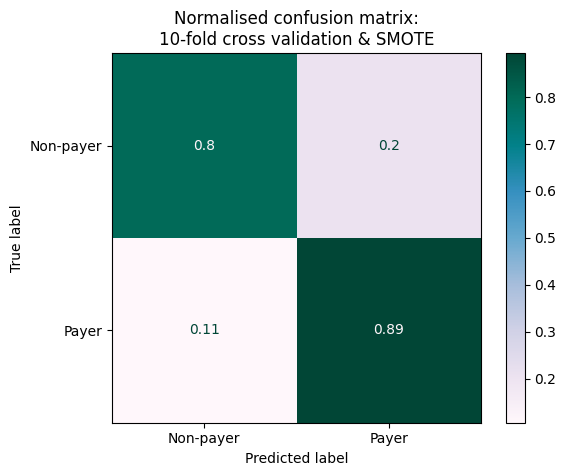

In [33]:
ConfusionMatrixDisplay.from_estimator(model, X_train_std, y_train,
                                      display_labels=['Non-payer','Payer'],
                                      cmap='PuBuGn',
                                      normalize='true'
                                      )
plt.title('Normalised confusion matrix:\n10-fold cross validation & SMOTE')
plt.show()

### Performance Metrics

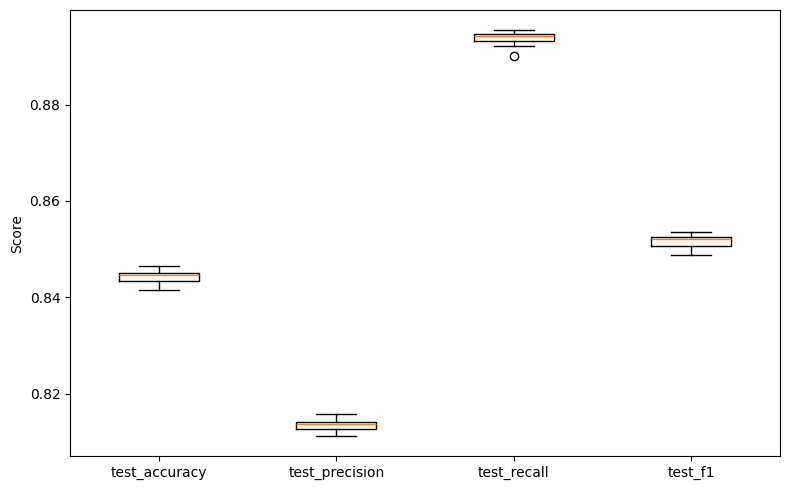

In [34]:
# plot distribution of performance metrics shown in classification report
performance_metrics = pd.DataFrame(cv_results).drop(
    columns=['fit_time', 'score_time', 'estimator'])

# plot metrics obtained via stratified kfolds
# the test_ metrics refer to the the 10th fold 
plt.subplots(figsize=(8,5))
plt.boxplot(performance_metrics, labels=performance_metrics.columns)
#plt.ylim(0.85, 0.9)
plt.ylabel('Score')
plt.tight_layout()
plt.show()

### ROC curve

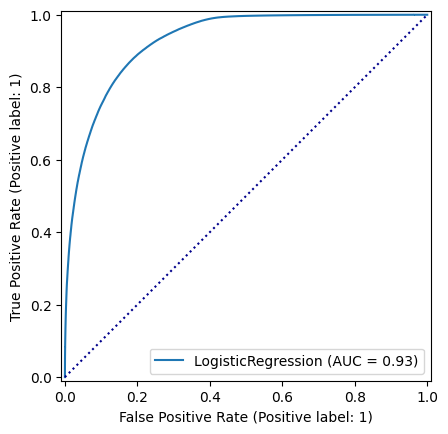

In [37]:
# receiver operator characteristic curve
# plot specificity (false positive rate) vs recall (aka sensitivity; true positive rate) 
roc_curve = RocCurveDisplay.from_estimator(model, X_train_std, y_train, pos_label=1)
fig = roc_curve.figure_
ax = roc_curve.ax_
# plot chance
ax.plot([0,1], [0,1], color='darkblue', linestyle=':')
plt.show()

**Next, I will test other ML approaches** and compare them against our baseline results from fitting a logistic regression.